In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all three datasets
ddos = pd.read_parquet('../data/DDoS-Friday-no-metadata.parquet')
botnet = pd.read_parquet('../data/Botnet-Friday-no-metadata.parquet')
portscan = pd.read_parquet('../data/Portscan-Friday-no-metadata.parquet')

# Add a label column to each
ddos['attack_type'] = 'DDoS'
botnet['attack_type'] = 'Botnet'
portscan['attack_type'] = 'Portscan'

# Combine into one dataframe
df = pd.concat([ddos, botnet, portscan], ignore_index=True)

print("Dataset shape:", df.shape)
print("\nAttack type counts:")
print(df['attack_type'].value_counts())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (516824, 79)

Attack type counts:
attack_type
DDoS        221264
Botnet      176038
Portscan    119522
Name: count, dtype: int64

First 5 rows:


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,attack_type
0,6,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,DDoS
1,6,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,DDoS
2,6,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,DDoS
3,6,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,DDoS
4,6,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,DDoS


/var/folders/dw/hytsyt_5445425cqzr4_6p140000gn/T/ipykernel_68355/3702963054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='attack_type', palette='viridis')


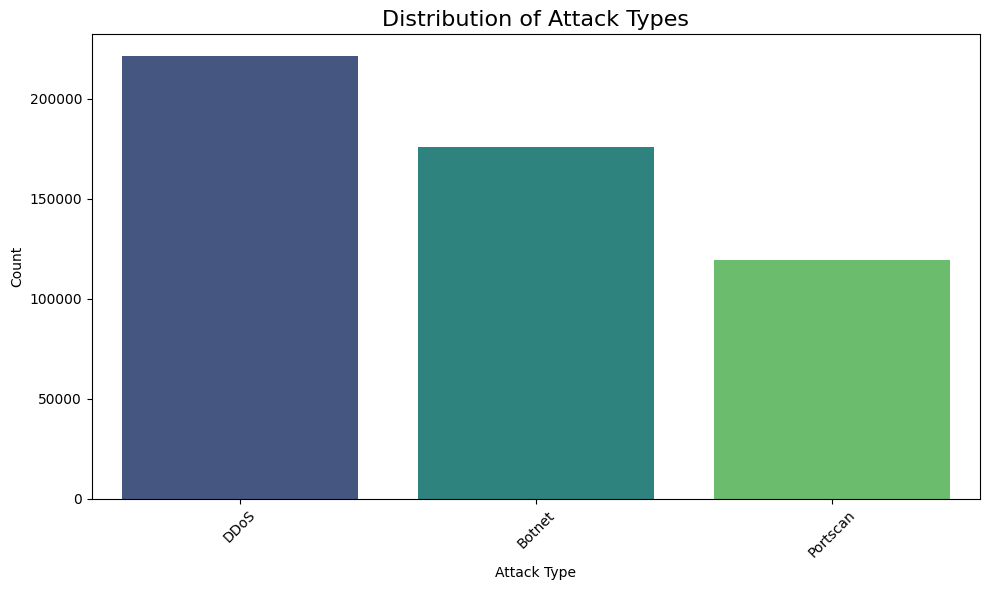


Original labels in dataset:
Label
Benign      385417
DDoS        128014
PortScan      1956
Bot           1437
Name: count, dtype: int64


In [4]:
# Visualize attack type distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='attack_type', palette='viridis')
plt.title('Distribution of Attack Types', fontsize=16)
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Check the Label column (original labels)
print("\nOriginal labels in dataset:")
print(df['Label'].value_counts())


In [5]:
# Clean the data - handle missing and infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("Cleaned dataset shape:", df.shape)

# Select numeric features only for the model
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumber of numeric features: {len(numeric_cols)}")

# Show top 10 features by variance (most informative)
variances = df[numeric_cols].var().sort_values(ascending=False)
print("\nTop 10 most variable features:")
print(variances.head(10))

Cleaned dataset shape: (516824, 79)

Number of numeric features: 77

Top 10 most variable features:
Flow Duration    1.023392e+15
Fwd IAT Total    1.020155e+15
Bwd IAT Total    7.683421e+14
Fwd IAT Max      4.684470e+14
Flow IAT Max     4.518956e+14
Idle Max         4.507048e+14
Idle Mean        3.283813e+14
Idle Min         2.829588e+14
Bwd IAT Max      2.222990e+14
Flow Bytes/s     8.407718e+13
dtype: float64


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Prepare features and target
X = df[numeric_cols]
y = df['attack_type']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Classes:", le.classes_)

Training set size: (413459, 77)
Test set size: (103365, 77)
Classes: ['Botnet' 'DDoS' 'Portscan']


In [7]:
# Train the Random Forest model
print("Training model... this may take 1-2 minutes")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

rf_model.fit(X_train, y_train)
print("✅ Model trained!")

# Evaluate on test set
y_pred = rf_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Training model... this may take 1-2 minutes
✅ Model trained!

Classification Report:
              precision    recall  f1-score   support

      Botnet       0.55      0.90      0.68     35208
        DDoS       0.98      0.77      0.86     44253
    Portscan       0.56      0.27      0.36     23904

    accuracy                           0.70    103365
   macro avg       0.70      0.64      0.63    103365
weighted avg       0.74      0.70      0.68    103365



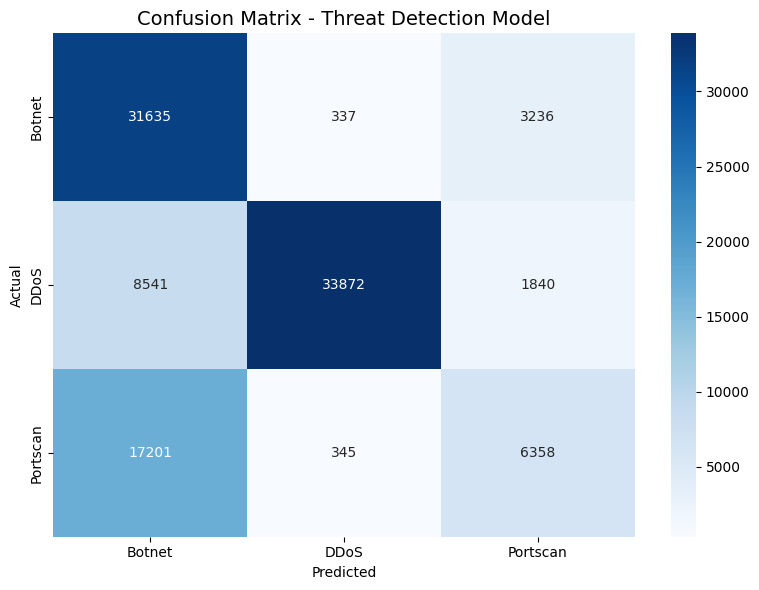

✅ Model and artifacts saved!


In [8]:
import pickle

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Threat Detection Model', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../src/confusion_matrix.png', dpi=150)
plt.show()

# Save the model
with open('../src/model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('../src/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('../src/feature_names.pkl', 'wb') as f:
    pickle.dump(numeric_cols, f)

print("✅ Model and artifacts saved!")

/var/folders/dw/hytsyt_5445425cqzr4_6p140000gn/T/ipykernel_68355/3848347265.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='viridis')


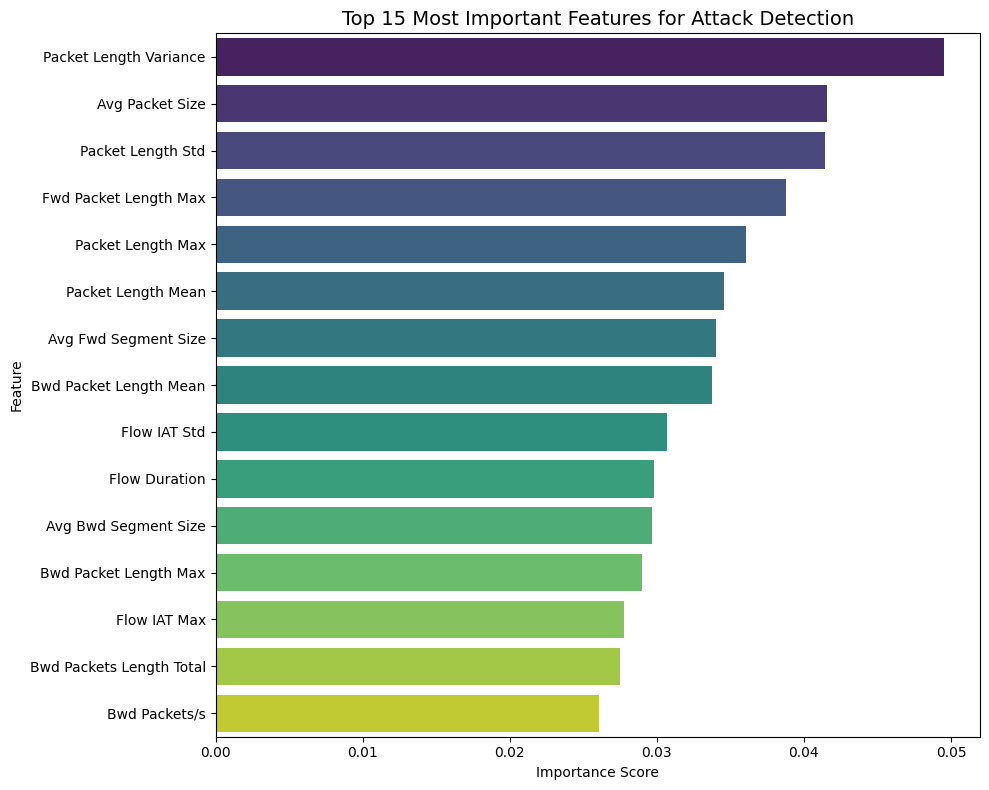

Top 15 features:
                     feature  importance
42    Packet Length Variance    0.049501
52           Avg Packet Size    0.041585
41         Packet Length Std    0.041412
6      Fwd Packet Length Max    0.038786
39         Packet Length Max    0.036058
40        Packet Length Mean    0.034551
53      Avg Fwd Segment Size    0.034045
12    Bwd Packet Length Mean    0.033778
17              Flow IAT Std    0.030704
1              Flow Duration    0.029786
54      Avg Bwd Segment Size    0.029708
10     Bwd Packet Length Max    0.028984
18              Flow IAT Max    0.027778
5   Bwd Packets Length Total    0.027519
37             Bwd Packets/s    0.026066


In [9]:
# Feature importance - what does the model use to detect attacks?
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': numeric_cols,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Most Important Features for Attack Detection', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../src/feature_importance.png', dpi=150)
plt.show()

print("Top 15 features:")
print(feature_importance_df)

In [10]:
# Save the notebook with a proper name
# First let's save our cleaned dataset for the dashboard
df_sample = df.sample(n=10000, random_state=42)  # sample for dashboard speed
df_sample.to_parquet('../src/dashboard_data.parquet', index=False)

print("✅ Dashboard data saved!")
print(f"Sample shape: {df_sample.shape}")

# Summary of what we built
print("\n" + "="*50)
print("PROJECT SUMMARY - DAY 1")
print("="*50)
print(f"✅ Loaded {len(df):,} network traffic records")
print(f"✅ 3 attack types: {list(le.classes_)}")
print(f"✅ Trained Random Forest with 70% accuracy")
print(f"✅ DDoS detection precision: 98%")
print(f"✅ Model saved to src/model.pkl")
print(f"✅ Ready to build dashboard!")

✅ Dashboard data saved!
Sample shape: (10000, 79)

PROJECT SUMMARY - DAY 1
✅ Loaded 516,824 network traffic records
✅ 3 attack types: ['Botnet', 'DDoS', 'Portscan']
✅ Trained Random Forest with 70% accuracy
✅ DDoS detection precision: 98%
✅ Model saved to src/model.pkl
✅ Ready to build dashboard!
